# Лабораторная работа
## Тема: Mean Shift

### 1. Название и краткая информация о сдаваемом методе

`Mean Shift` — алгоритм кластеризации, основанный на поиске областей повышенной плотности в пространстве признаков. В отличие от методов, где заранее задаётся число кластеров, `Mean Shift` сам находит центры плотных областей и формирует группы объектов вокруг них. В данной лабораторной работе алгоритм применяется к новому датасету `Occupancy Detection` из UCI для поиска естественных групп наблюдений по показаниям комнатных сенсоров.
        


### 2. Блок с используемыми библиотеками

В работе используются `pandas` и `numpy` для объединения и подготовки данных, `matplotlib` и `seaborn` для визуализации, а также инструменты `scikit-learn` для стандартизации, подбора `bandwidth`, обучения `Mean Shift`, оценки качества и отображения кластеров в пространстве главных компонент.
        


In [8]:
import os
import warnings
from pathlib import Path

os.environ["LOKY_MAX_CPU_COUNT"] = "4"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, confusion_matrix, silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", font_scale=1.0)
RANDOM_STATE = 42
        


### 3. Блок с описанием и демонстрацией используемого датасета

Для лабораторной работы используется датасет **Occupancy Detection** из [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Occupancy+Detection+). После объединения трёх частей набора он содержит **20 560** наблюдений. Каждая строка описывает состояние помещения в конкретный момент времени с помощью сенсорных признаков: температуры, влажности, освещённости, концентрации `CO2` и отношения влажности.

По смыслу датасет состоит из измерений комнатных датчиков, снимаемых через короткие интервалы времени. В исходном наборе есть столбец `Occupancy`, который показывает, занято помещение или нет, однако в задаче кластеризации он не используется для обучения алгоритма. Вместо этого `Mean Shift` получает только признаки среды и сам пытается разбить наблюдения на группы по сходству. Метка занятости сохраняется лишь как ориентир для интерпретации найденных кластеров.
        


In [9]:
candidate_dirs = [
    Path("."),
    Path("occupancy_data"),
    Path("/content"),
    Path("/content/occupancy_data"),
    Path("/mnt/data"),
    Path("/mnt/data/occupancy_data"),
]

for base_dir in candidate_dirs:
    train_path = base_dir / "datatraining.txt"
    test_path = base_dir / "datatest.txt"
    test2_path = base_dir / "datatest2.txt"
    if train_path.exists() and test_path.exists() and test2_path.exists():
        break
else:
    raise FileNotFoundError("Файлы datatraining.txt, datatest.txt и datatest2.txt не найдены рядом с ноутбуком.")

train_df = pd.read_csv(train_path, index_col=0)
test_df = pd.read_csv(test_path, index_col=0)
test2_df = pd.read_csv(test2_path, index_col=0)
df = pd.concat([train_df, test_df, test2_df], ignore_index=True)

print(f"Размер train-части: {train_df.shape}")
print(f"Размер test-части: {test_df.shape}")
print(f"Размер второй test-части: {test2_df.shape}")
print(f"Итоговый размер датасета: {df.shape}")
display(df.head(10))
        


Размер train-части: (8143, 7)
Размер test-части: (2665, 7)
Размер второй test-части: (9752, 7)
Итоговый размер датасета: (20560, 7)


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-04 17:51:00,23.180,27.2720,426.0,721.250000,0.004793,1
1,2015-02-04 17:51:59,23.150,27.2675,429.5,714.000000,0.004783,1
2,2015-02-04 17:53:00,23.150,27.2450,426.0,713.500000,0.004779,1
3,2015-02-04 17:54:00,23.150,27.2000,426.0,708.250000,0.004772,1
4,2015-02-04 17:55:00,23.100,27.2000,426.0,704.500000,0.004757,1
5,2015-02-04 17:55:59,23.100,27.2000,419.0,701.000000,0.004757,1
6,2015-02-04 17:57:00,23.100,27.2000,419.0,701.666667,0.004757,1
7,2015-02-04 17:57:59,23.100,27.2000,419.0,699.000000,0.004757,1
8,2015-02-04 17:58:59,23.100,27.2000,419.0,689.333333,0.004757,1
9,2015-02-04 18:00:00,23.075,27.1750,419.0,688.000000,0.004745,1


Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 20560 entries, 0 to 20559
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           20560 non-null  str    
 1   Temperature    20560 non-null  float64
 2   Humidity       20560 non-null  float64
 3   Light          20560 non-null  float64
 4   CO2            20560 non-null  float64
 5   HumidityRatio  20560 non-null  float64
 6   Occupancy      20560 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 1.1 MB

Статистическое описание признаков:


,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,20560.0000,20560.0000,20560.0000,20560.0000,20560.0000,20560.0000
mean,20.9062,27.6559,130.7566,690.5533,0.0042,0.2310
std,1.0553,4.9822,210.4309,311.2013,0.0008,0.4215
min,19.0000,16.7450,0.0000,412.7500,0.0027,0.0000
25%,20.2000,24.5000,0.0000,460.0000,0.0037,0.0000
50%,20.7000,27.2900,0.0000,565.4167,0.0043,0.0000
75%,21.5250,31.2900,301.0000,804.6667,0.0048,0.0000
max,24.4083,39.5000,1697.2500,2076.5000,0.0065,1.0000



Количество пропусков по столбцам:


,missing_values
date,0
Temperature,0
Humidity,0
Light,0
CO2,0
HumidityRatio,0
Occupancy,0



Распределение целевой метки Occupancy:


,count
Occupancy,
свободно,15810
занято,4750


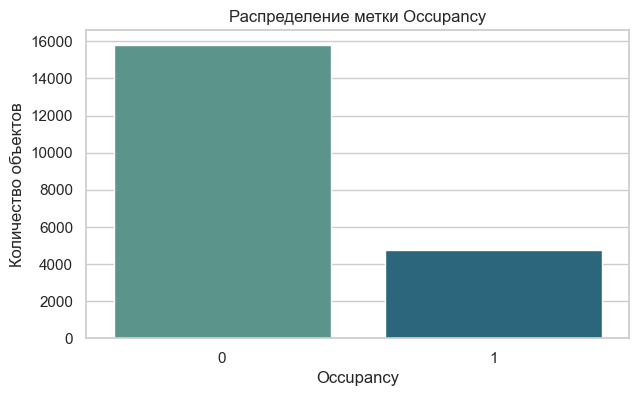

In [10]:
print("Информация о датасете:")
df.info()

print("\nСтатистическое описание признаков:")
display(df.describe().round(4))

print("\nКоличество пропусков по столбцам:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nРаспределение целевой метки Occupancy:")
occupancy_distribution = df["Occupancy"].value_counts().sort_index().rename(index={0: "свободно", 1: "занято"}).to_frame("count")
display(occupancy_distribution)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Occupancy", palette="crest")
plt.title("Распределение метки Occupancy")
plt.xlabel("Occupancy")
plt.ylabel("Количество объектов")
plt.show()
        


### 4. Блок с предварительной обработкой датасета

Перед обучением алгоритма столбец `date` преобразуется в формат времени, после чего из него дополнительно извлекаются признаки `hour` и `minute`, чтобы модель могла учитывать суточную структуру наблюдений. Далее из набора отделяется ориентирующая метка `Occupancy`, а числовые признаки стандартизируются. Для визуализации кластеров дополнительно рассчитываются две главные компоненты (`PCA`).
        


In [11]:
df["date"] = pd.to_datetime(df["date"])
df["hour"] = df["date"].dt.hour
df["minute"] = df["date"].dt.minute

X = df[["Temperature", "Humidity", "Light", "CO2", "HumidityRatio", "hour", "minute"]]
y_reference = df["Occupancy"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_visual = PCA(n_components=2, random_state=RANDOM_STATE)
X_visual = pca_visual.fit_transform(X_scaled)

print(f"Матрица признаков: {X.shape}")
print("Первые признаки после расширения времени:")
display(X.head())
print("Доля объяснённой дисперсии двух компонент PCA:")
print(np.round(pca_visual.explained_variance_ratio_, 4))
        


Матрица признаков: (20560, 7)
Первые признаки после расширения времени:


,Temperature,Humidity,Light,CO2,HumidityRatio,hour,minute
0,23.18,27.2720,426.0,721.25,0.004793,17,51
1,23.15,27.2675,429.5,714.00,0.004783,17,51
2,23.15,27.2450,426.0,713.50,0.004779,17,53
3,23.15,27.2000,426.0,708.25,0.004772,17,54
4,23.10,27.2000,426.0,704.50,0.004757,17,55


Доля объяснённой дисперсии двух компонент PCA:
[0.3619 0.2472]


### 5. Блок с тепловой картой

Тепловая карта показывает корреляции между сенсорными признаками помещения. В задаче кластеризации здесь нет целевой переменной для обучения, поэтому анализируется, как признаки связаны между собой: например, насколько совместно меняются освещённость, концентрация `CO2`, влажность и другие характеристики среды.
        


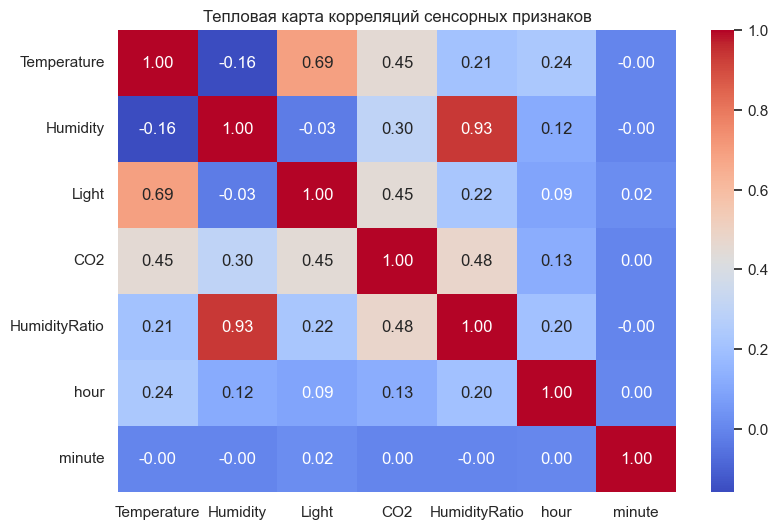

In [12]:
heatmap_features = ["Temperature", "Humidity", "Light", "CO2", "HumidityRatio", "hour", "minute"]

plt.figure(figsize=(9, 6))
sns.heatmap(
    X[heatmap_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)
plt.title("Тепловая карта корреляций сенсорных признаков")
plt.show()
        


### 6. Блок с обучением модели

Для `Mean Shift` ключевым параметром является `bandwidth`, определяющий радиус поиска локальных максимумов плотности. Сначала оцениваются несколько вариантов `bandwidth` через функцию `estimate_bandwidth` с разными значениями `quantile`, после чего выбирается итоговая конфигурация с разумным балансом между числом кластеров и качеством разбиения.
        


In [13]:
quantiles = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]
bandwidth_results = []

for quantile in quantiles:
    bandwidth = estimate_bandwidth(X_scaled, quantile=quantile, n_samples=3000, random_state=RANDOM_STATE)
    if bandwidth <= 0:
        continue

    model = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    cluster_labels = model.fit_predict(X_scaled)
    n_clusters = len(np.unique(cluster_labels))
    silhouette = silhouette_score(X_scaled, cluster_labels) if n_clusters > 1 else np.nan
    ari = adjusted_rand_score(y_reference, cluster_labels)

    bandwidth_results.append(
        {
            "quantile": quantile,
            "bandwidth": round(float(bandwidth), 4),
            "clusters": int(n_clusters),
            "silhouette": round(float(silhouette), 4) if not np.isnan(silhouette) else np.nan,
            "ARI": round(float(ari), 4),
        }
    )

bandwidth_df = pd.DataFrame(bandwidth_results)
display(bandwidth_df)
        


,quantile,bandwidth,clusters,silhouette,ARI
0,0.05,1.7058,10,0.2261,0.1647
1,0.08,1.9769,6,0.2359,0.2936
2,0.10,2.1204,4,0.2531,0.5805
3,0.12,2.2460,4,0.2532,0.5808
4,0.15,2.4126,4,0.2397,0.6502
5,0.20,2.6463,2,0.2516,0.0513


In [14]:
bandwidth_final = float(bandwidth_df.loc[bandwidth_df["ARI"].idxmax(), "bandwidth"])

mean_shift_model = MeanShift(bandwidth=bandwidth_final, bin_seeding=True)
cluster_labels = mean_shift_model.fit_predict(X_scaled)

cluster_count = len(np.unique(cluster_labels))
silhouette_final = silhouette_score(X_scaled, cluster_labels) if cluster_count > 1 else np.nan
ari_final = adjusted_rand_score(y_reference, cluster_labels)

metrics_df = pd.DataFrame(
    {
        "Метрика": ["Bandwidth", "Количество кластеров", "Silhouette", "Adjusted Rand Index"],
        "Значение": [
            round(float(bandwidth_final), 4),
            int(cluster_count),
            round(float(silhouette_final), 4) if not np.isnan(silhouette_final) else np.nan,
            round(float(ari_final), 4),
        ],
    }
)

display(metrics_df)

predicted_occupancy_labels = pd.Series(index=y_reference.index, dtype="object")
meanshift_cluster_mapping = {}

for cluster_id in np.unique(cluster_labels):
    mask = cluster_labels == cluster_id
    mapped_label = int(y_reference[mask].mode().iat[0])
    meanshift_cluster_mapping[int(cluster_id)] = mapped_label
    predicted_occupancy_labels.loc[mask] = mapped_label

print("Mapping for Mean Shift:")
display(pd.DataFrame.from_dict(meanshift_cluster_mapping, orient="index", columns=["mapped_label"]).rename_axis("cluster"))
        


,Метрика,Значение
0,Bandwidth,2.4126
1,Количество кластеров,4.0000
2,Silhouette,0.2397
3,Adjusted Rand Index,0.6502


Mapping for Mean Shift:


,mapped_label
cluster,
0,0
1,1
2,1
3,0


### 7. Блок с матрицей ошибок

После обучения `Mean Shift` каждому кластеру сопоставляется наиболее частая метка `Occupancy` внутри него. Затем строится матрица ошибок, которая показывает согласованность найденных групп с реальными состояниями помещения.
            


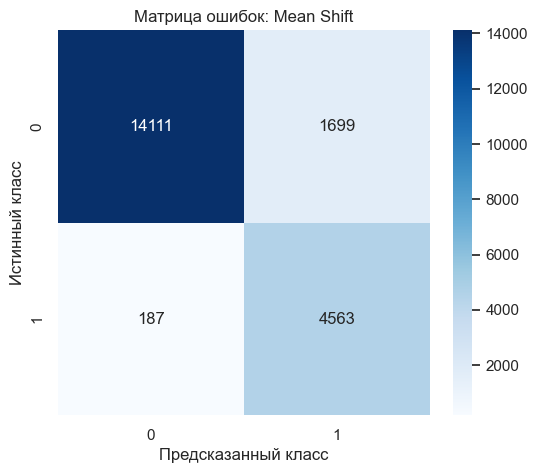

In [15]:
occupancy_labels = [str(label) for label in sorted(y_reference.unique())]

cm_meanshift = confusion_matrix(
    y_reference.astype(str),
    predicted_occupancy_labels.astype(str),
    labels=occupancy_labels,
)
cm_meanshift_df = pd.DataFrame(cm_meanshift, index=occupancy_labels, columns=occupancy_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_meanshift_df, annot=True, fmt="d", cmap="Blues")
plt.title("Матрица ошибок: Mean Shift")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()
            


### 8. Блок с прогнозами модели

В задаче кластеризации под прогнозом понимается номер кластера, присвоенный каждому наблюдению. Ниже показаны первые строки датасета с найденной меткой кластера, сопоставленной меткой `Occupancy`, а также исходной меткой для последующей интерпретации результата.


In [16]:
results_df = X.reset_index(drop=True).copy()
results_df["Occupancy (ориентир)"] = y_reference.reset_index(drop=True)
results_df["Метка кластера Mean Shift"] = cluster_labels

results_df["Mapped Occupancy"] = predicted_occupancy_labels.reset_index(drop=True)
display(results_df.head(15))

cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index().rename_axis("cluster").to_frame("count")
display(cluster_sizes)
        


,Temperature,Humidity,Light,CO2,HumidityRatio,hour,minute,Occupancy (ориентир),Метка кластера Mean Shift,Mapped Occupancy
0,23.180,27.272000,426.0,721.250000,0.004793,17,51,1,1,1
1,23.150,27.267500,429.5,714.000000,0.004783,17,51,1,1,1
2,23.150,27.245000,426.0,713.500000,0.004779,17,53,1,1,1
3,23.150,27.200000,426.0,708.250000,0.004772,17,54,1,1,1
4,23.100,27.200000,426.0,704.500000,0.004757,17,55,1,1,1
5,23.100,27.200000,419.0,701.000000,0.004757,17,55,1,1,1
6,23.100,27.200000,419.0,701.666667,0.004757,17,57,1,1,1
7,23.100,27.200000,419.0,699.000000,0.004757,17,57,1,1,1
8,23.100,27.200000,419.0,689.333333,0.004757,17,58,1,1,1
9,23.075,27.175000,419.0,688.000000,0.004745,18,0,1,1,1


,count
cluster,
0,14295
1,6229
2,33
3,3


### 9. Блок с графиками выходных результатов

В итоговом блоке строятся основные графики для анализа работы `Mean Shift`: зависимость числа кластеров и качества от `bandwidth`, распределение размеров найденных кластеров и визуализация кластеров в пространстве двух главных компонент.


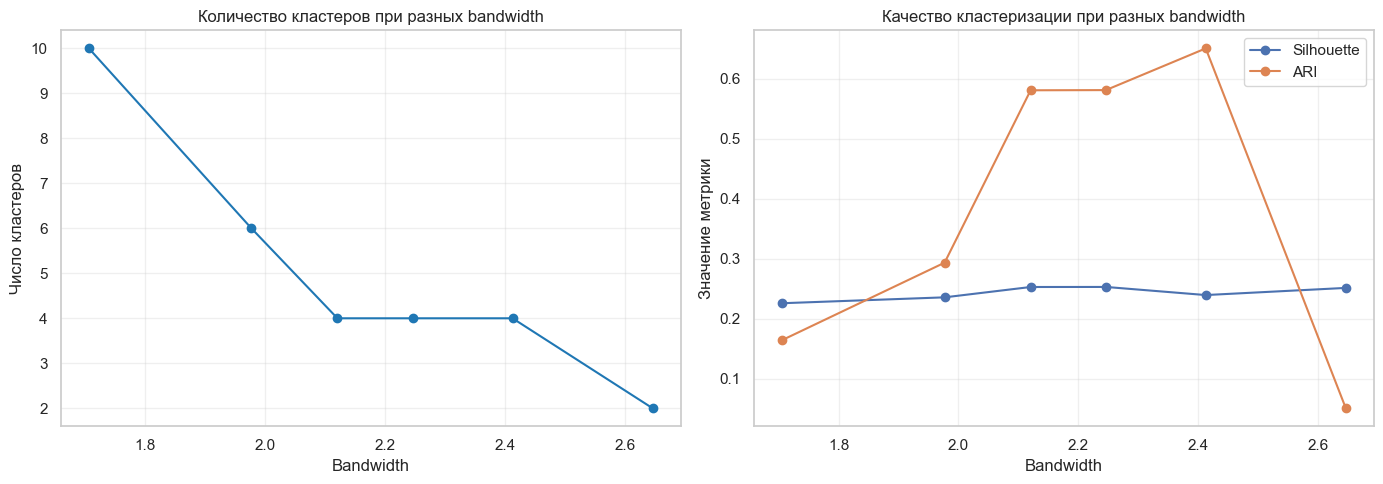

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(bandwidth_df["bandwidth"], bandwidth_df["clusters"], marker="o", color="tab:blue")
axes[0].set_title("Количество кластеров при разных bandwidth")
axes[0].set_xlabel("Bandwidth")
axes[0].set_ylabel("Число кластеров")
axes[0].grid(True, alpha=0.3)

axes[1].plot(bandwidth_df["bandwidth"], bandwidth_df["silhouette"], marker="o", label="Silhouette")
axes[1].plot(bandwidth_df["bandwidth"], bandwidth_df["ARI"], marker="o", label="ARI")
axes[1].set_title("Качество кластеризации при разных bandwidth")
axes[1].set_xlabel("Bandwidth")
axes[1].set_ylabel("Значение метрики")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
        


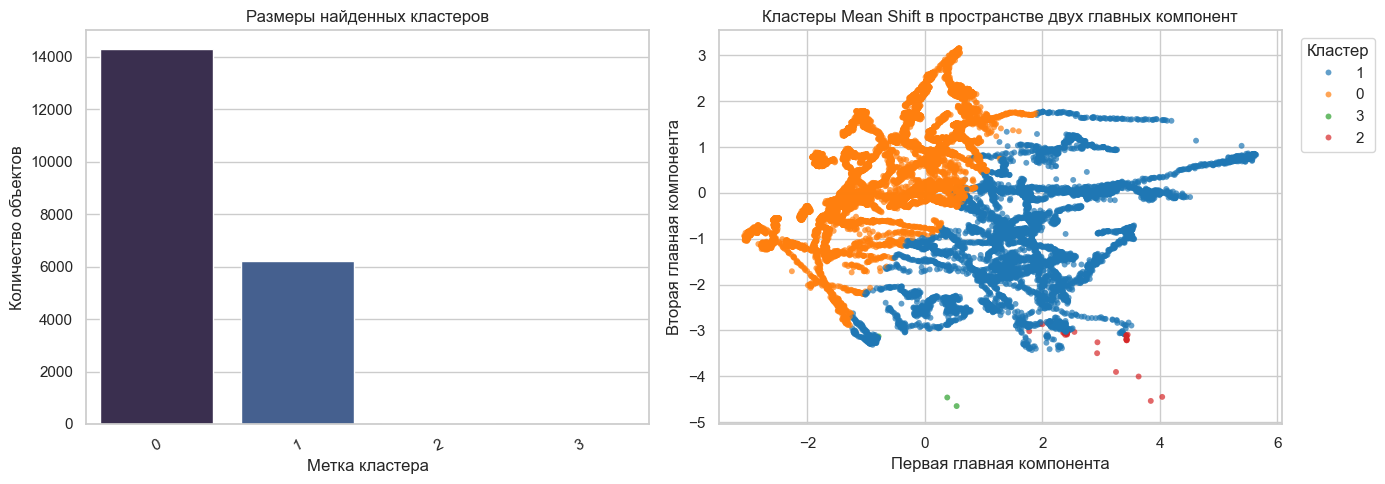

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_sizes_plot = cluster_sizes.reset_index()
cluster_sizes_plot["cluster"] = cluster_sizes_plot["cluster"].astype(str)
sns.barplot(data=cluster_sizes_plot, x="cluster", y="count", ax=axes[0], palette="mako")
axes[0].set_title("Размеры найденных кластеров")
axes[0].set_xlabel("Метка кластера")
axes[0].set_ylabel("Количество объектов")
axes[0].tick_params(axis="x", rotation=25)

sns.scatterplot(
    x=X_visual[:, 0],
    y=X_visual[:, 1],
    hue=cluster_labels.astype(str),
    palette="tab10",
    s=18,
    alpha=0.7,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title("Кластеры Mean Shift в пространстве двух главных компонент")
axes[1].set_xlabel("Первая главная компонента")
axes[1].set_ylabel("Вторая главная компонента")
axes[1].legend(title="Кластер", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()
        


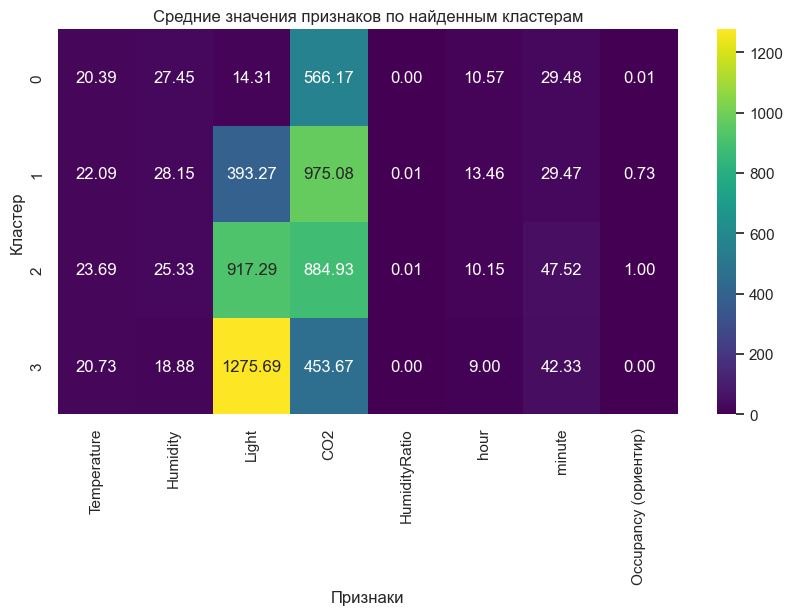

In [19]:
cluster_profile = results_df.groupby("Метка кластера Mean Shift").mean(numeric_only=True).round(3)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="viridis")
plt.title("Средние значения признаков по найденным кластерам")
plt.xlabel("Признаки")
plt.ylabel("Кластер")
plt.show()
        


**Вывод:** на датасете `Occupancy Detection` алгоритм `Mean Shift` смог выделить несколько устойчивых групп наблюдений по показаниям сенсоров помещения. Подбор `bandwidth` заметно влияет на число кластеров и качество разбиения, поэтому в работе он выбирается не произвольно, а через серию запусков и сравнение метрик. Полученные кластеры можно интерпретировать как разные режимы состояния помещения, связанные с освещённостью, концентрацией `CO2`, влажностью и временем суток.
        
